# Gesture Recognition — Training (Mandatory Gestures)

Trains a neural network for the **mandatory gesture set** (idle, sl, sr, r_cw).

**Requirements covered:**
- **M1:** Neural network from scratch (NumPy only)
- **M2:** Detection of mandatory gestures
- **O2:** PCA dimensionality reduction
- **O12:** Optimizer comparison (SGD vs Momentum vs Adam)

**Prerequisites:** Run `gesture_recognition_preproc.ipynb` for all 3 teammates first.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add model_creation to path for module imports
sys.path.insert(0, str(Path('.').resolve()))

from helper_functions import (
    relu, relu_derivative, softmax,
    cross_entropy_loss, accuracy, f1_score,
    plot_metrics, confusion_matrix_np, plot_confusion_matrix,
    save_training_history, load_training_history,
    load_multiple_histories, plot_model_comparison,
    plot_multi_model_summary
)
from adam_neural_net import NeuralNetwork
from pca_functions import ManualPCA

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

PROCESSED_DIR = Path("../data/processed")
EDA_DIR = Path("../visualizations/training")
EDA_DIR.mkdir(parents=True, exist_ok=True)

print("Imports OK")
print(f"Visualizations will be saved to: {EDA_DIR.resolve()}")

Imports OK


## Step 1: Load & Combine Preprocessed Data

Load per-person preprocessed CSVs (created by the Preproc notebook) and combine.

In [2]:
files = {
    "arun": PROCESSED_DIR / "arun_preprocessed.csv",
    "aswathy": PROCESSED_DIR / "aswathy_preprocessed.csv",
    "nayana": PROCESSED_DIR / "nayana_preprocessed.csv",
}

dfs = {}
for name, path in files.items():
    if path.exists():
        dfs[name] = pd.read_csv(path)
        print(f"{name}: {dfs[name].shape} | labels: {dict(dfs[name]['label'].value_counts())}")
    else:
        print(f"WARNING: {path} not found — skipping")

combined_df = pd.concat(dfs.values(), ignore_index=True)
print(f"\nCombined: {combined_df.shape}")
print(combined_df["label"].value_counts())

arun: (4309, 94) | labels: {'idle': np.int64(3186), 'r_ccw': np.int64(256), 'r_cw': np.int64(233), 'sd': np.int64(199), 'su': np.int64(176), 'sr': np.int64(136), 'sl': np.int64(123)}
aswathy: (3631, 94) | labels: {'idle': np.int64(2857), 'r_ccw': np.int64(191), 'r_cw': np.int64(189), 'su': np.int64(118), 'sr': np.int64(103), 'sl': np.int64(98), 'sd': np.int64(75)}
nayana: (3390, 94) | labels: {'idle': np.int64(2485), 'r_ccw': np.int64(169), 'r_cw': np.int64(164), 'sd': np.int64(158), 'sr': np.int64(157), 'sl': np.int64(145), 'su': np.int64(112)}

Combined: (11330, 94)
label
idle     8528
r_ccw     616
r_cw      586
sd        432
su        406
sr        396
sl        366
Name: count, dtype: int64


## Step 2: Filter Mandatory Labels Only

Keep only idle, sl, sr, r_cw — drop any optional labels that might be present.

In [3]:
MANDATORY_LABELS = {"idle", "sl", "sr", "r_cw"}

before = len(combined_df)
combined_df = combined_df[combined_df["label"].isin(MANDATORY_LABELS)].reset_index(drop=True)
print(f"Filtered: {before} -> {len(combined_df)} (kept mandatory only)")
print(combined_df["label"].value_counts())

Filtered: 11330 -> 9876 (kept mandatory only)
label
idle    8528
r_cw     586
sr       396
sl       366
Name: count, dtype: int64


## Step 3: Create Sliding Windows

Window size = 18 frames at 30 FPS = 0.6 seconds. Stride = 5 frames.
Label = center frame of the window.

In [4]:
# ---- Window settings ----
TARGET_FPS = 30
WINDOW_SEC = 0.6
STRIDE_SEC = 0.15

WINDOW_SIZE = int(round(TARGET_FPS * WINDOW_SEC))   # 18
STRIDE = int(round(TARGET_FPS * STRIDE_SEC))        # ~5

print(f"WINDOW_SIZE: {WINDOW_SIZE} frames ({WINDOW_SEC}s)")
print(f"STRIDE: {STRIDE} frames")

# ---- Identify feature columns ----
NON_FEATURES = {"gesture_type", "ground_truth", "label", "person", "source_file", "time"}
feature_cols = [c for c in combined_df.columns if c not in NON_FEATURES]
print(f"Feature columns: {len(feature_cols)}")

# ---- Create windows per source file ----
def make_windows(df, feature_cols, window, stride):
    X_all, y_all = [], []
    mid = window // 2
    for _, g in df.groupby("source_file"):
        g = g.sort_values("time").reset_index(drop=True)
        feats = g[feature_cols].to_numpy(dtype=np.float32)
        labels = g["label"].to_numpy()
        if len(g) < window:
            continue
        for start in range(0, len(g) - window + 1, stride):
            X_all.append(feats[start:start+window])
            y_all.append(labels[start + mid])  # center-frame label
    return np.stack(X_all), np.array(y_all)

X_win, y_win = make_windows(combined_df, feature_cols, WINDOW_SIZE, STRIDE)
print(f"\nX_win: {X_win.shape}")
print(f"y_win: {y_win.shape}")
print(f"Window labels: {dict(zip(*np.unique(y_win, return_counts=True)))}")

WINDOW_SIZE: 18 frames (0.6s)
STRIDE: 4 frames
Feature columns: 90

X_win: (2409, 18, 90)
y_win: (2409,)
Window labels: {np.str_('idle'): np.int64(2075), np.str_('r_cw'): np.int64(145), np.str_('sl'): np.int64(92), np.str_('sr'): np.int64(97)}


## Step 4: Balance Dataset (Undersample Idle)

In [5]:
y = np.array([str(v) for v in y_win])

idle_idx = np.where(y == "idle")[0]
gesture_idx = np.where(y != "idle")[0]

IDLE_RATIO = 2  # keep 2x idle vs total gesture windows
target_idle = min(len(idle_idx), IDLE_RATIO * len(gesture_idx))

rng = np.random.default_rng(42)
idle_keep = rng.choice(idle_idx, size=target_idle, replace=False)
keep_idx = np.concatenate([gesture_idx, idle_keep])
rng.shuffle(keep_idx)

X_bal = X_win[keep_idx]
y_bal = y[keep_idx]

print(f"Balanced: {X_bal.shape}")
print(f"Distribution: {dict(zip(*np.unique(y_bal, return_counts=True)))}")

Balanced: (1002, 18, 90)
Distribution: {np.str_('idle'): np.int64(668), np.str_('r_cw'): np.int64(145), np.str_('sl'): np.int64(92), np.str_('sr'): np.int64(97)}


## Step 5: Label Encoding + Flatten + Split + Standardize

In [6]:
# ---- Label encoding ----
unique_labels = sorted(np.unique(y_bal))
label_to_idx = {label: i for i, label in enumerate(unique_labels)}
idx_to_label = {i: label for label, i in label_to_idx.items()}
NUM_CLASSES = len(unique_labels)

print("Label mapping:")
for label, idx in label_to_idx.items():
    count = np.sum(y_bal == label)
    print(f"  {label:8s} -> {idx}  ({count} windows)")

y_int = np.array([label_to_idx[l] for l in y_bal], dtype=np.int32)

def one_hot_encode(y_int, num_classes):
    one_hot = np.zeros((len(y_int), num_classes), dtype=np.float32)
    one_hot[np.arange(len(y_int)), y_int] = 1.0
    return one_hot

y_onehot = one_hot_encode(y_int, NUM_CLASSES)

# ---- Flatten windows ----
N, W, F = X_bal.shape
X_flat = X_bal.reshape(N, W * F).astype(np.float64)
input_dim = W * F
print(f"\nFlattened: {X_bal.shape} -> {X_flat.shape}")

# ---- Stratified split (NumPy only) ----
def stratified_split(X, y_int, y_oh, train_r=0.70, val_r=0.15, seed=42):
    rng = np.random.default_rng(seed)
    train_idx, val_idx, test_idx = [], [], []
    for cls in np.unique(y_int):
        ci = np.where(y_int == cls)[0]
        rng.shuffle(ci)
        n_train = int(round(len(ci) * train_r))
        n_val = int(round(len(ci) * val_r))
        train_idx.extend(ci[:n_train])
        val_idx.extend(ci[n_train:n_train + n_val])
        test_idx.extend(ci[n_train + n_val:])
    for idx in [train_idx, val_idx, test_idx]:
        idx_arr = np.array(idx)
        rng.shuffle(idx_arr)
        idx[:] = idx_arr.tolist()
    ti, vi, tsi = np.array(train_idx), np.array(val_idx), np.array(test_idx)
    return (X[ti], y_int[ti], y_oh[ti],
            X[vi], y_int[vi], y_oh[vi],
            X[tsi], y_int[tsi], y_oh[tsi])

X_train, y_train_int, y_train_oh, \
X_val,   y_val_int,   y_val_oh, \
X_test,  y_test_int,  y_test_oh = stratified_split(X_flat, y_int, y_onehot)

print(f"\nSplit: Train={X_train.shape[0]}, Val={X_val.shape[0]}, Test={X_test.shape[0]}")

# ---- Standardize (fit on train only) ----
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)
train_std[train_std == 0] = 1.0

X_train = (X_train - train_mean) / train_std
X_val   = (X_val   - train_mean) / train_std
X_test  = (X_test  - train_mean) / train_std

print(f"Standardized. X_train mean range: [{X_train.mean(axis=0).min():.6f}, {X_train.mean(axis=0).max():.6f}]")

Label mapping:
  idle     -> 0  (668 windows)
  r_cw     -> 1  (145 windows)
  sl       -> 2  (92 windows)
  sr       -> 3  (97 windows)

Flattened: (1002, 18, 90) -> (1002, 1620)

Split: Train=702, Val=151, Test=149
Standardized. X_train mean range: [-0.000000, 0.000000]


## Step 6: Train Neural Network — M1

Architecture: `Input(1620) -> Dense(256, ReLU, Dropout=0.3) -> Dense(128, ReLU, Dropout=0.3) -> Dense(4, Softmax)`

Optimizer: Adam with LR scheduling + early stopping.

In [7]:
# ---- Metrics functions ----
def accuracy_fn(y_pred_idx, y_true_idx):
    return np.mean(y_pred_idx == y_true_idx)

def f1_macro(y_pred_idx, y_true_idx, num_classes):
    f1s = []
    for c in range(num_classes):
        tp = np.sum((y_pred_idx == c) & (y_true_idx == c))
        fp = np.sum((y_pred_idx == c) & (y_true_idx != c))
        fn = np.sum((y_pred_idx != c) & (y_true_idx == c))
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        f1s.append(f1)
    return np.mean(f1s)

def ce_loss(y_pred, y_true):
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

# ---- Training function ----
def train_model(model, X_train, y_train_oh, y_train_int,
                X_val, y_val_oh, y_val_int,
                epochs=150, batch_size=64,
                optimizer='adam', lr=0.001,
                patience=20, lr_patience=10, lr_factor=0.5, seed=42):
    model.init_optimizer(optimizer=optimizer, lr=lr)
    rng = np.random.default_rng(seed)
    n_train = X_train.shape[0]
    n_batches = max(1, n_train // batch_size)
    nc = y_train_oh.shape[1]

    history = {'train_loss': [], 'val_loss': [],
               'train_acc': [], 'val_acc': [],
               'train_f1': [], 'val_f1': [], 'lr': []}

    best_val_loss = np.inf
    best_weights, best_biases = None, None
    wait, lr_wait, current_lr = 0, 0, lr

    for epoch in range(1, epochs + 1):
        model.training = True
        perm = rng.permutation(n_train)
        X_shuf, y_shuf = X_train[perm], y_train_oh[perm]

        for b in range(n_batches):
            s, e = b * batch_size, min((b+1) * batch_size, n_train)
            y_pred = model.forward(X_shuf[s:e])
            grads_w, grads_b = model.backward(y_shuf[s:e])
            model.update(grads_w, grads_b)

        # Evaluate
        tr_pred = model.predict(X_train)
        tr_proba = model.predict_proba(X_train)
        tr_loss = ce_loss(tr_proba, y_train_oh)
        tr_acc = accuracy_fn(tr_pred, y_train_int)
        tr_f1 = f1_macro(tr_pred, y_train_int, nc)

        v_pred = model.predict(X_val)
        v_proba = model.predict_proba(X_val)
        v_loss = ce_loss(v_proba, y_val_oh)
        v_acc = accuracy_fn(v_pred, y_val_int)
        v_f1 = f1_macro(v_pred, y_val_int, nc)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(v_acc)
        history['train_f1'].append(tr_f1)
        history['val_f1'].append(v_f1)
        history['lr'].append(current_lr)

        marker = ""
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_weights = [w.copy() for w in model.weights]
            best_biases = [b.copy() for b in model.biases]
            wait, lr_wait = 0, 0
            marker = " *"
        else:
            wait += 1
            lr_wait += 1

        if lr_wait >= lr_patience and current_lr > 1e-6:
            current_lr *= lr_factor
            model.lr = current_lr
            lr_wait = 0
            print(f"  >> LR reduced to {current_lr:.6f}")

        if epoch % 10 == 0 or epoch == 1 or wait == 0:
            print(f"Epoch {epoch:3d} | T Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} F1: {tr_f1:.3f} | "
                  f"V Loss: {v_loss:.4f} Acc: {v_acc:.3f} F1: {v_f1:.3f} lr={current_lr:.5f}{marker}")

        if wait >= patience:
            print(f"\nEarly stopping at epoch {epoch}")
            break

    if best_weights:
        model.weights = best_weights
        model.biases = best_biases
        print(f"Restored best weights (val_loss={best_val_loss:.4f})")

    return history

print("Training function defined")

Training function defined


In [8]:
# ---- Build and train the main model ----
model = NeuralNetwork(
    layer_sizes=[input_dim, 256, 128, NUM_CLASSES],
    dropout_rate=0.3,
    l2_lambda=1e-4,
    seed=42
)

print(f"Architecture: {model.layer_sizes}")
print(f"Parameters: {sum(w.size + b.size for w, b in zip(model.weights, model.biases)):,}")
print(f"Dropout: {model.dropout_rate}, L2: {model.l2_lambda}")

history = train_model(
    model, X_train, y_train_oh, y_train_int,
    X_val, y_val_oh, y_val_int,
    epochs=300, batch_size=64,
    optimizer='adam', lr=0.001,
    patience=40, lr_patience=15, lr_factor=0.5
)

Architecture: [1620, 256, 128, 4]
Parameters: 448,388
Dropout: 0.3, L2: 0.0001
Epoch   1 | T Loss: 0.4532 Acc: 0.872 F1: 0.788 | V Loss: 0.6024 Acc: 0.821 F1: 0.680 lr=0.00100 *
Epoch   2 | T Loss: 0.1506 Acc: 0.947 F1: 0.925 | V Loss: 0.3337 Acc: 0.914 F1: 0.903 lr=0.00100 *
Epoch   3 | T Loss: 0.0586 Acc: 0.984 F1: 0.977 | V Loss: 0.2682 Acc: 0.921 F1: 0.895 lr=0.00100 *
Epoch   4 | T Loss: 0.0271 Acc: 0.987 F1: 0.980 | V Loss: 0.1904 Acc: 0.934 F1: 0.905 lr=0.00100 *
Epoch   5 | T Loss: 0.0307 Acc: 0.990 F1: 0.985 | V Loss: 0.1849 Acc: 0.934 F1: 0.923 lr=0.00100 *
Epoch   6 | T Loss: 0.0160 Acc: 0.994 F1: 0.992 | V Loss: 0.1843 Acc: 0.954 F1: 0.947 lr=0.00100 *
Epoch   7 | T Loss: 0.0127 Acc: 0.994 F1: 0.992 | V Loss: 0.1351 Acc: 0.947 F1: 0.932 lr=0.00100 *
Epoch   8 | T Loss: 0.0067 Acc: 0.999 F1: 0.998 | V Loss: 0.1282 Acc: 0.954 F1: 0.947 lr=0.00100 *
Epoch  10 | T Loss: 0.0064 Acc: 0.997 F1: 0.996 | V Loss: 0.1448 Acc: 0.960 F1: 0.952 lr=0.00100
Epoch  15 | T Loss: 0.0004 Acc: 

## Step 7: Learning Curves & Test Evaluation

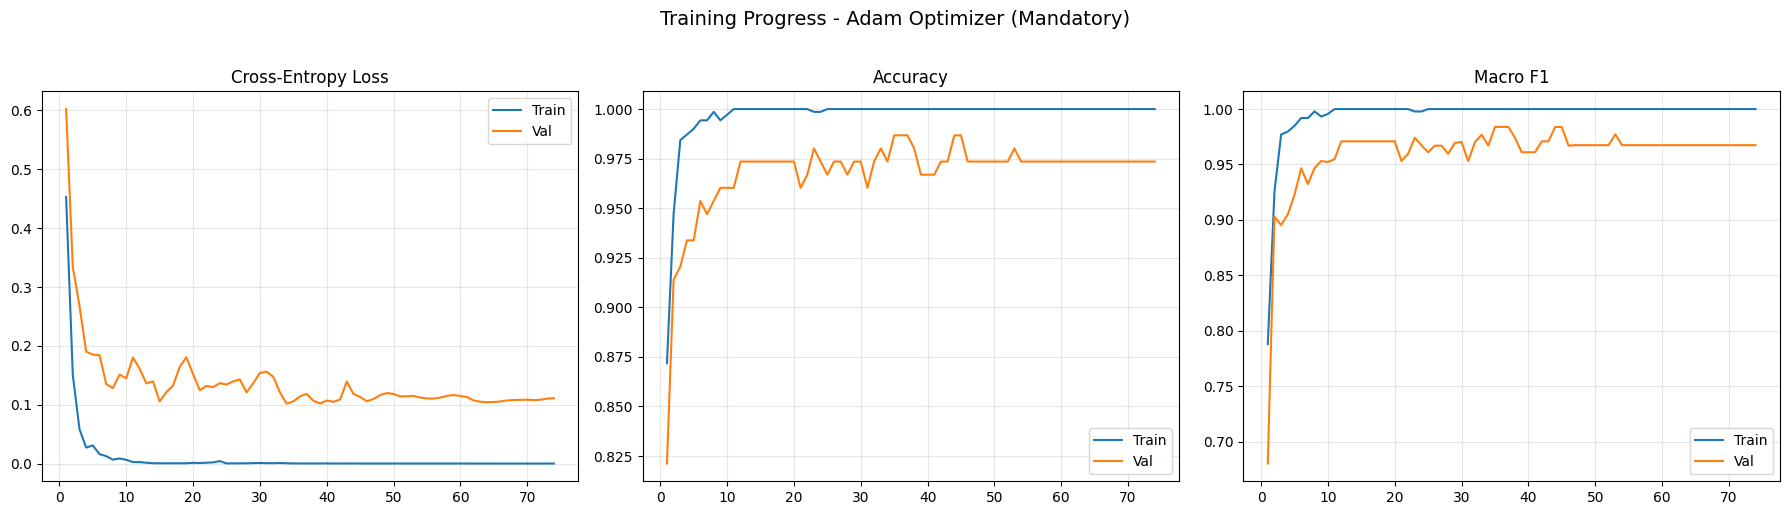

In [ ]:
# ---- Learning Curves ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = np.arange(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'], label='Val')
axes[0].set_title('Cross-Entropy Loss'); axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], label='Train')
axes[1].plot(epochs_range, history['val_acc'], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend()

axes[2].plot(epochs_range, history['train_f1'], label='Train')
axes[2].plot(epochs_range, history['val_f1'], label='Val')
axes[2].set_title('Macro F1'); axes[2].legend()

plt.suptitle('Training Progress - Adam Optimizer (Mandatory)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(str(EDA_DIR / 'learning_curves_mandatory.png'), dpi=150, bbox_inches='tight')
plt.show()

# ---- O1.1: Save raw training history for later comparison ----
save_training_history(
    history, EDA_DIR / 'history_adam_mandatory.npz',
    model_name='Adam (Mandatory, 4-class)',
    metadata={'architecture': str(model.layer_sizes), 'optimizer': 'adam', 'lr': 0.001}
)

TEST SET RESULTS (Mandatory Gestures)
  Loss     : 0.1370
  Accuracy : 0.9664  (144/149)
  Macro F1 : 0.9562

Class            Prec   Recall       F1  Support
------------------------------------------------
idle            0.952    1.000    0.976      100
r_cw            1.000    0.857    0.923       21
sl              1.000    0.929    0.963       14
sr              1.000    0.929    0.963       14


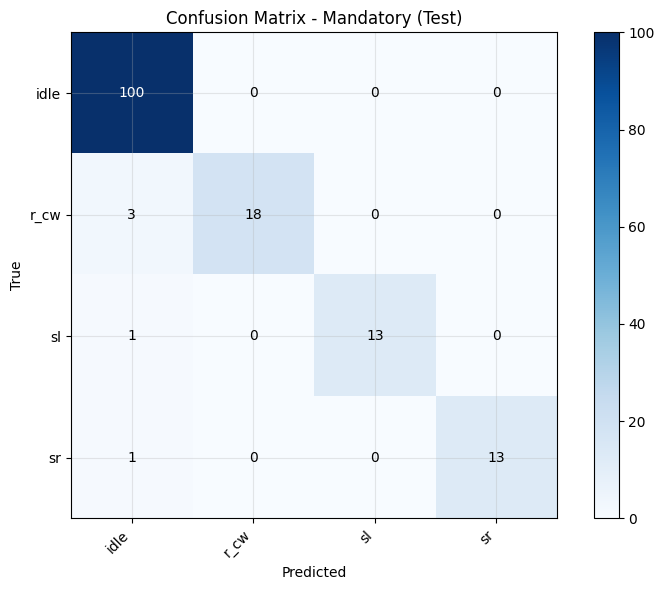

<Figure size 640x480 with 0 Axes>

In [ ]:
# ---- Test Set Evaluation ----
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)

test_loss = ce_loss(y_test_proba, y_test_oh)
test_acc = accuracy_fn(y_test_pred, y_test_int)
test_f1 = f1_macro(y_test_pred, y_test_int, NUM_CLASSES)

print("=" * 50)
print("TEST SET RESULTS (Mandatory Gestures)")
print("=" * 50)
print(f"  Loss     : {test_loss:.4f}")
print(f"  Accuracy : {test_acc:.4f}  ({int(test_acc * len(y_test_int))}/{len(y_test_int)})")
print(f"  Macro F1 : {test_f1:.4f}")
print("=" * 50)

# Per-class metrics
print(f"\n{'Class':<12} {'Prec':>8} {'Recall':>8} {'F1':>8} {'Support':>8}")
print("-" * 48)
for c in range(NUM_CLASSES):
    tp = np.sum((y_test_pred == c) & (y_test_int == c))
    fp = np.sum((y_test_pred == c) & (y_test_int != c))
    fn = np.sum((y_test_pred != c) & (y_test_int == c))
    support = np.sum(y_test_int == c)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    print(f"{idx_to_label[c]:<12} {prec:>8.3f} {rec:>8.3f} {f1:>8.3f} {support:>8d}")

# Confusion matrix (saved via save_path parameter)
cm = confusion_matrix_np(y_test_int, y_test_pred, NUM_CLASSES)
class_names = [idx_to_label[i] for i in range(NUM_CLASSES)]
plot_confusion_matrix(cm, class_names=class_names,
                      title='Confusion Matrix - Mandatory (Test)',
                      save_path=EDA_DIR / 'confusion_matrix_mandatory.png')

## Step 8: O12 — Optimizer Comparison (SGD vs Momentum vs Adam)

All three models use the same architecture `[1620, 256, 128, 4]`, dropout=0.3, L2=1e-4.

In [11]:
def fresh_model(seed=42):
    return NeuralNetwork(
        layer_sizes=[input_dim, 256, 128, NUM_CLASSES],
        dropout_rate=0.3, l2_lambda=1e-4, seed=seed
    )

COMMON = dict(epochs=200, batch_size=64, patience=30,
              lr_patience=200, lr_factor=0.5, seed=42)

# SGD
print("=" * 60 + "\nTraining: SGD (lr=0.1)\n" + "=" * 60)
model_sgd = fresh_model()
history_sgd = train_model(model_sgd, X_train, y_train_oh, y_train_int,
                          X_val, y_val_oh, y_val_int,
                          optimizer='sgd', lr=0.1, **COMMON)

# Momentum
print("\n" + "=" * 60 + "\nTraining: Momentum (lr=0.01)\n" + "=" * 60)
model_mom = fresh_model()
history_mom = train_model(model_mom, X_train, y_train_oh, y_train_int,
                          X_val, y_val_oh, y_val_int,
                          optimizer='momentum', lr=0.01, **COMMON)

# Adam — reuse from main training
history_adam = history
print("\nAdam: reusing history from main training.")

Training: SGD (lr=0.1)
Epoch   1 | T Loss: 0.6714 Acc: 0.843 F1: 0.833 | V Loss: 0.7460 Acc: 0.841 F1: 0.821 lr=0.10000 *
Epoch   2 | T Loss: 0.2261 Acc: 0.934 F1: 0.911 | V Loss: 0.2464 Acc: 0.927 F1: 0.913 lr=0.10000 *
Epoch   4 | T Loss: 0.0589 Acc: 0.979 F1: 0.968 | V Loss: 0.2296 Acc: 0.921 F1: 0.898 lr=0.10000 *
Epoch   5 | T Loss: 0.0518 Acc: 0.983 F1: 0.975 | V Loss: 0.1628 Acc: 0.927 F1: 0.917 lr=0.10000 *
Epoch   6 | T Loss: 0.0321 Acc: 0.990 F1: 0.986 | V Loss: 0.1589 Acc: 0.954 F1: 0.948 lr=0.10000 *
Epoch   7 | T Loss: 0.0193 Acc: 0.993 F1: 0.990 | V Loss: 0.1483 Acc: 0.960 F1: 0.947 lr=0.10000 *
Epoch   8 | T Loss: 0.0281 Acc: 0.993 F1: 0.990 | V Loss: 0.0949 Acc: 0.960 F1: 0.954 lr=0.10000 *
Epoch  10 | T Loss: 0.0167 Acc: 0.997 F1: 0.996 | V Loss: 0.1291 Acc: 0.960 F1: 0.955 lr=0.10000
Epoch  15 | T Loss: 0.0042 Acc: 1.000 F1: 1.000 | V Loss: 0.0930 Acc: 0.967 F1: 0.960 lr=0.10000 *
Epoch  20 | T Loss: 0.0022 Acc: 1.000 F1: 1.000 | V Loss: 0.0853 Acc: 0.967 F1: 0.965 lr

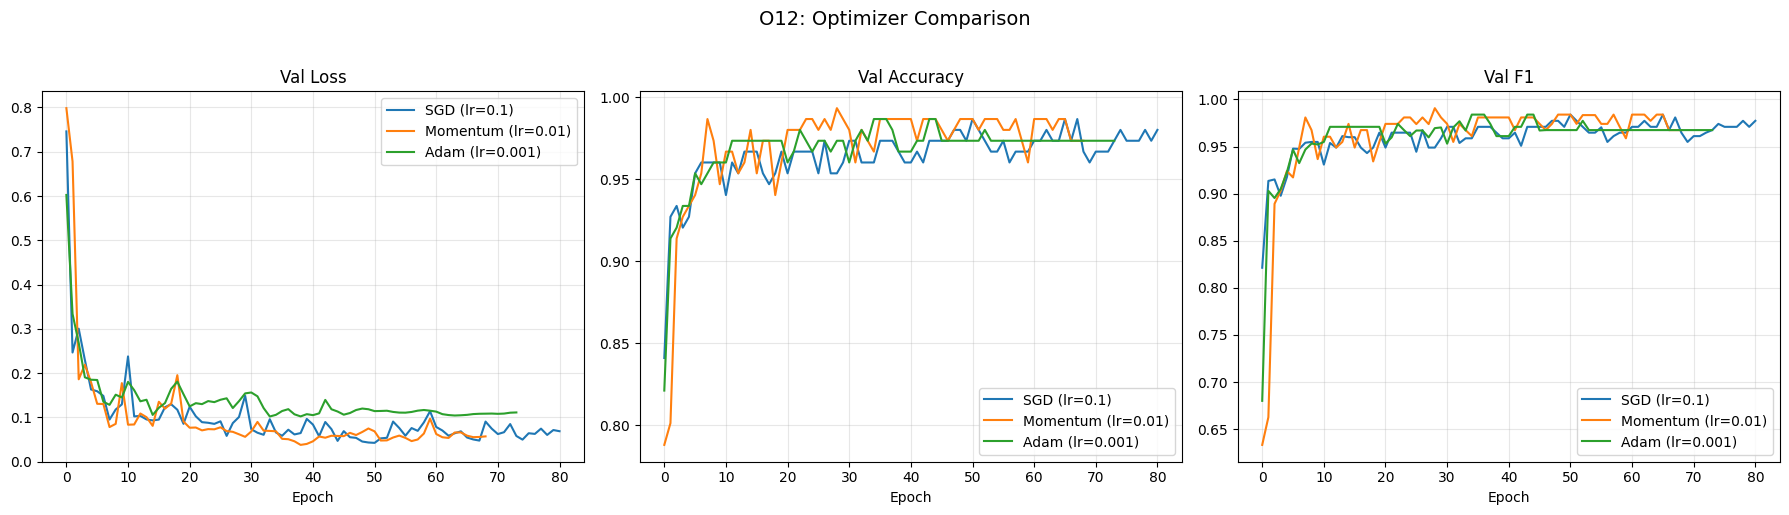


 O12 OPTIMIZER COMPARISON - TEST SET
  SGD          | Acc: 0.9664 | F1: 0.9488 | Loss: 0.1198
  Momentum     | Acc: 0.9799 | F1: 0.9745 | Loss: 0.0787
  Adam         | Acc: 0.9664 | F1: 0.9562 | Loss: 0.1370


In [ ]:
# ---- O12 Comparison Plot ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

runs = [
    ('SGD (lr=0.1)',       history_sgd,  'tab:blue'),
    ('Momentum (lr=0.01)', history_mom,  'tab:orange'),
    ('Adam (lr=0.001)',    history_adam,  'tab:green'),
]

for ax, key, title in zip(axes, ['val_loss', 'val_acc', 'val_f1'],
                           ['Val Loss', 'Val Accuracy', 'Val F1']):
    for name, h, c in runs:
        ax.plot(h[key], label=name, color=c)
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('O12: Optimizer Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(str(EDA_DIR / 'optimizer_comparison_mandatory.png'), dpi=150, bbox_inches='tight')
plt.show()

# Test set comparison
print("\n" + "=" * 65)
print(" O12 OPTIMIZER COMPARISON - TEST SET")
print("=" * 65)
for name, m in [('SGD', model_sgd), ('Momentum', model_mom), ('Adam', model)]:
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)
    acc = accuracy_fn(pred, y_test_int)
    f1 = f1_macro(pred, y_test_int, NUM_CLASSES)
    loss = ce_loss(proba, y_test_oh)
    print(f"  {name:<12} | Acc: {acc:.4f} | F1: {f1:.4f} | Loss: {loss:.4f}")
print("=" * 65)

# ---- O1.1: Save raw histories for each optimizer ----
save_training_history(
    history_sgd, EDA_DIR / 'history_sgd_mandatory.npz',
    model_name='SGD (Mandatory)',
    metadata={'optimizer': 'sgd', 'lr': 0.1}
)
save_training_history(
    history_mom, EDA_DIR / 'history_momentum_mandatory.npz',
    model_name='Momentum (Mandatory)',
    metadata={'optimizer': 'momentum', 'lr': 0.01}
)

## Step 9: O2 — PCA Dimensionality Reduction

Manual PCA via eigendecomposition of covariance matrix (NumPy only).
Compare model performance with and without PCA.

  90% variance -> 71 components
  95% variance -> 111 components
  99% variance -> 201 components


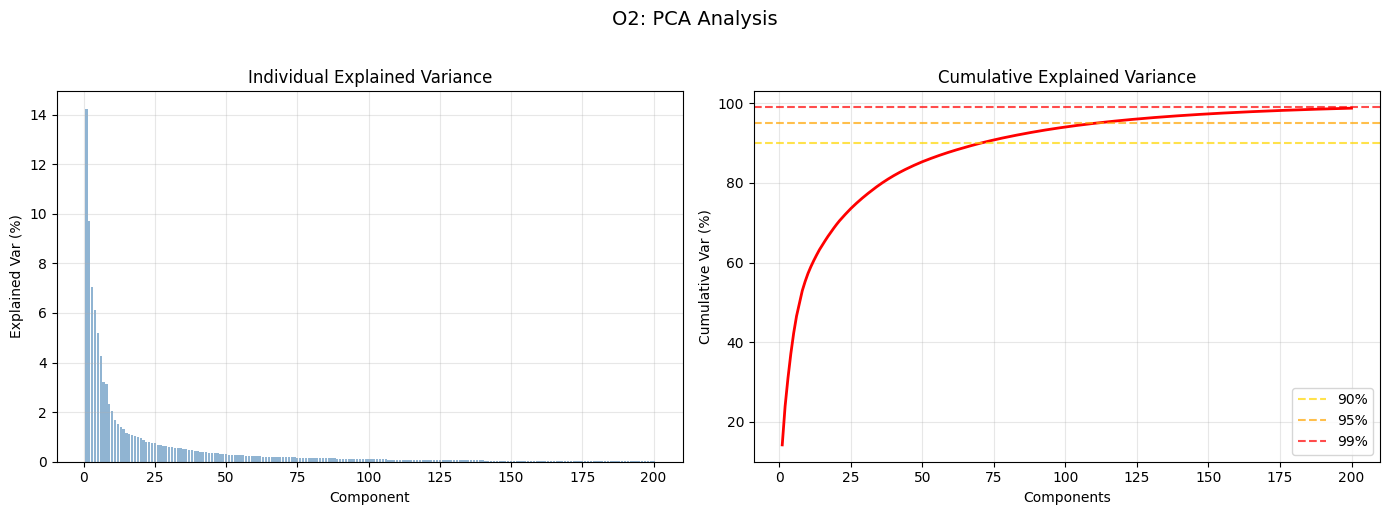

In [13]:
# ---- PCA Analysis: explained variance ----
pca_analysis = ManualPCA(n_components=200)
X_train_pca200 = pca_analysis.fit_transform(X_train)

cumvar = np.cumsum(pca_analysis.explained_variance_ratio)

for t in [0.90, 0.95, 0.99]:
    n = np.searchsorted(cumvar, t) + 1
    print(f"  {t*100:.0f}% variance -> {n} components")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
n_show = min(200, len(pca_analysis.explained_variance_ratio))

axes[0].bar(range(1, n_show+1), pca_analysis.explained_variance_ratio[:n_show]*100,
            alpha=0.6, color='steelblue')
axes[0].set_xlabel('Component'); axes[0].set_ylabel('Explained Var (%)')
axes[0].set_title('Individual Explained Variance')

axes[1].plot(range(1, n_show+1), cumvar[:n_show]*100, 'r-', linewidth=2)
for t, c in zip([0.90, 0.95, 0.99], ['gold', 'orange', 'red']):
    axes[1].axhline(y=t*100, color=c, linestyle='--', alpha=0.7, label=f'{t*100:.0f}%')
axes[1].set_xlabel('Components'); axes[1].set_ylabel('Cumulative Var (%)')
axes[1].set_title('Cumulative Explained Variance'); axes[1].legend()

plt.suptitle('O2: PCA Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(str(EDA_DIR / 'pca_analysis_mandatory.png'), dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ---- Train on PCA-reduced features ----
N_PCA = 150
pca_o2 = ManualPCA(n_components=N_PCA)
X_train_pca = pca_o2.fit_transform(X_train)
X_val_pca = pca_o2.transform(X_val)
X_test_pca = pca_o2.transform(X_test)

print(f"PCA: {X_train.shape[1]} -> {X_train_pca.shape[1]} features")
print(f"Variance retained: {np.cumsum(pca_o2.explained_variance_ratio)[-1]*100:.1f}%")

model_pca = NeuralNetwork(
    layer_sizes=[N_PCA, 128, 128, NUM_CLASSES],
    dropout_rate=0.2, l2_lambda=1e-5, seed=42
)
print(f"Architecture: {model_pca.layer_sizes}")

history_pca = train_model(
    model_pca, X_train_pca, y_train_oh, y_train_int,
    X_val_pca, y_val_oh, y_val_int,
    epochs=200, batch_size=64, optimizer='adam', lr=0.001,
    patience=30, lr_patience=200, lr_factor=0.5
)

# Compare
print("\n" + "=" * 60)
print("PCA COMPARISON - TEST SET")
print("=" * 60)
for label, m, X_te in [
    (f'No PCA (d={input_dim})', model, X_test),
    (f'PCA (d={N_PCA})',        model_pca, X_test_pca),
]:
    pred = m.predict(X_te)
    proba = m.predict_proba(X_te)
    acc = accuracy_fn(pred, y_test_int)
    f1 = f1_macro(pred, y_test_int, NUM_CLASSES)
    loss = ce_loss(proba, y_test_oh)
    params = sum(w.size + b.size for w, b in zip(m.weights, m.biases))
    print(f"  {label:<30} | Acc: {acc:.4f} | F1: {f1:.4f} | Params: {params:,}")
print("=" * 60)

PCA: 1620 -> 150 features
Variance retained: 97.3%
Architecture: [150, 128, 128, 4]
Epoch   1 | T Loss: 0.6681 Acc: 0.799 F1: 0.683 | V Loss: 0.7265 Acc: 0.768 F1: 0.601 lr=0.00100 *
Epoch   2 | T Loss: 0.3375 Acc: 0.879 F1: 0.831 | V Loss: 0.3968 Acc: 0.861 F1: 0.802 lr=0.00100 *
Epoch   3 | T Loss: 0.1963 Acc: 0.932 F1: 0.901 | V Loss: 0.2312 Acc: 0.901 F1: 0.871 lr=0.00100 *
Epoch   4 | T Loss: 0.1302 Acc: 0.957 F1: 0.939 | V Loss: 0.1817 Acc: 0.934 F1: 0.915 lr=0.00100 *
Epoch   5 | T Loss: 0.0923 Acc: 0.973 F1: 0.961 | V Loss: 0.1372 Acc: 0.947 F1: 0.929 lr=0.00100 *
Epoch   6 | T Loss: 0.0635 Acc: 0.983 F1: 0.976 | V Loss: 0.1284 Acc: 0.947 F1: 0.933 lr=0.00100 *
Epoch   7 | T Loss: 0.0499 Acc: 0.983 F1: 0.978 | V Loss: 0.1204 Acc: 0.967 F1: 0.954 lr=0.00100 *
Epoch   8 | T Loss: 0.0451 Acc: 0.990 F1: 0.987 | V Loss: 0.1158 Acc: 0.947 F1: 0.937 lr=0.00100 *
Epoch   9 | T Loss: 0.0325 Acc: 0.990 F1: 0.986 | V Loss: 0.1065 Acc: 0.974 F1: 0.969 lr=0.00100 *
Epoch  10 | T Loss: 0.026

## Step 10: Save Model Weights

Save the trained model, scaler, and label mapping for deployment (M3 + M6).

In [15]:
SAVE_DIR = Path('.')  # Save in model_creation/
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Model weights
weights_path = SAVE_DIR / 'model_weights.npz'
np.savez(
    weights_path,
    **{f'W{i}': w for i, w in enumerate(model.weights)},
    **{f'b{i}': b for i, b in enumerate(model.biases)},
    layer_sizes=np.array(model.layer_sizes),
)
print(f"Saved model weights -> {weights_path}")

# Scaler
scaler_path = SAVE_DIR / 'scaler_params.npz'
np.savez(scaler_path, mean=train_mean, std=train_std)
print(f"Saved scaler -> {scaler_path}")

# Label mapping
labels_path = SAVE_DIR / 'label_mapping.npz'
np.savez(
    labels_path,
    labels=np.array(list(label_to_idx.keys())),
    indices=np.array(list(label_to_idx.values())),
)
print(f"Saved label mapping -> {labels_path}")
print(f"  Classes: {label_to_idx}")

# Also save to data/processed for backward compatibility
for src, dst_dir in [(weights_path, PROCESSED_DIR), (scaler_path, PROCESSED_DIR), (labels_path, PROCESSED_DIR)]:
    import shutil
    shutil.copy2(src, dst_dir / src.name)
print(f"\nAlso copied to {PROCESSED_DIR} for backward compatibility.")

# Verify
loaded = np.load(weights_path)
print(f"\nVerification: W0={loaded['W0'].shape}, layers={loaded['layer_sizes']}")
print("All model artifacts saved successfully.")

Saved model weights -> model_weights.npz
Saved scaler -> scaler_params.npz
Saved label mapping -> label_mapping.npz
  Classes: {np.str_('idle'): 0, np.str_('r_cw'): 1, np.str_('sl'): 2, np.str_('sr'): 3}

Also copied to ..\data\processed for backward compatibility.

Verification: W0=(1620, 256), layers=[1620  256  128    4]
All model artifacts saved successfully.


## Step 11: O1.1 — Load & Compare Multiple Models

Demonstrate loading saved training histories and generating combined comparison plots.
This functionality allows comparing any set of trained models side-by-side.

In [ ]:
# ---- O1.1: Load saved histories and generate combined comparison ----
# Load all optimizer histories saved earlier
histories = load_multiple_histories(
    EDA_DIR / 'history_adam_mandatory.npz',
    EDA_DIR / 'history_sgd_mandatory.npz',
    EDA_DIR / 'history_momentum_mandatory.npz',
)

# Combined 3-panel comparison (Loss, Accuracy, F1)
plot_multi_model_summary(
    histories,
    save_path=EDA_DIR / 'multi_model_comparison_mandatory.png'
)

# Individual metric comparisons
plot_model_comparison(
    histories, metric='val_loss',
    title='Optimizer Comparison — Validation Loss',
    save_path=EDA_DIR / 'comparison_val_loss_mandatory.png'
)
plot_model_comparison(
    histories, metric='val_f1',
    title='Optimizer Comparison — Validation Macro F1',
    save_path=EDA_DIR / 'comparison_val_f1_mandatory.png'
)

print("\nAll O1.1 comparison visualizations saved to:", EDA_DIR.resolve())